# Spotify RecSystem End to End (Sistema de Recomendação Spotify de Ponta a Ponta)
**[EN-US]**

Recommendation system, which recommends songs from Spotify. Created end-to-end, i.e. connecting and authorizing with the [Spotify API](https://developer.spotify.com/documentation/web-api), extracting data from the API, performing exploratory analysis, creating the model and producing the model.

**[PT-BR]**

Sistema de recomendação, que recomenda músicas do Spotify. Criado de ponta a ponta, ou seja, a conexão e autorização com a [Spotify API](https://developer.spotify.com/documentation/web-api), extração dos dados da API, realização da anaálise exploratória, criação do modelo e produção do modelo.

## Table of Contents
* [Packages](#1)
* [Environment Variables](#2)
* [Utils Functions](#3)
    * [Ingestion Functions](#3.1)
        * [Request Authorization](#3.1.1)
        * [Playlist Extraction](#3.1.2)
        * [Track Features Extraction](#3.1.3)
        * [Playlist to DataFrame](#3.1.4)
    * [Pre-Processing Functions](#3.2)
        * [Get User Dataset](#3.2.1)
    * [Plot Functions](#3.3)
        * [Get Pairs](#3.3.1)
        * [Plot Histogram](#3.3.2)
    * [Model FUnction](#3.4)
        * [User Neural Network](#3.4.1)
        * [Item Neural Network](#3.4.1)
        * [Model Compile](#3.4.1)
* [Playlist Data Extraction](#4)
    * [Request Authorization](#4.1)
    * [Playlists Definition](#4.2)
    * [Data Extraction and Preparation](#4.3)
* [Exploratory Data Analysis](#5)
* [Model](#Model)
    * [Content-Based Filtering Algorithm](#6.1)
    * [Content-Based Filtering Model](#6.2)

<a name="1"></a>
## Packages (Pacotes)
**[EN-US]**
* [os](https://docs.python.org/3/library/os.html): built-in module, provides a portable way of using operating system dependent functionality.
* [requests](https://pypi.org/project/requests/): is a simple HTTP library, for making HTTP requests.
* [base64](https://docs.python.org/pt-br/3.7/library/base64.html): provides functions for encoding binary data to printable ASCII characters and decoding such encodings back to binary data.
* [dotenv](https://pypi.org/project/python-dotenv/): reads key-value pairs from a .env file and can set them as environment variables.
* [pandas](https://pandas.pydata.org/): is the main package for data manipulation.
* [numpy](www.numpy.org): is the main package for scientific computing.
* [tensorflow](https://www.tensorflow.org/): framework that makes it easy to create ML models that can run in any environment.
* [scikit-learn](https://scikit-learn.org/stable/): open source machine learning library.
* [matplotlib](http://matplotlib.org): is a library to plot graphs.

**[PT-BR]**
* [os](https://docs.python.org/3/library/os.html): módulo integrado, fornece uma maneira portátil de usar funcionalidades dependentes do sistema operacional.
* [requests](https://pypi.org/project/requests/): é uma biblioteca HTTP simples, para fazer solicitações HTTP.
* [base64](https://docs.python.org/pt-br/3.7/library/base64.html): fornece funções para codificar dados binários em caracteres ASCII imprimíveis e decodificar essas codificações de volta para dados binários.
* [dotenv](https://pypi.org/project/python-dotenv/): lê pares de chave-valor de um arquivo .env e pode defini-los como variáveis de ambiente.
* [pandas](https://pandas.pydata.org/): é o principal pacote para manipulação de dados.
* [numpy](www.numpy.org): é o principal pacote para computação científica.
* [tensorflow](https://www.tensorflow.org/): framework que facilita a criação de modelos de machine learning que podem ser executados em qualquer ambiente.
* [scikit-learn](https://scikit-learn.org/stable/): biblioteca open-source de machine learning.
* [matplotlib](http://matplotlib.org): é uma biblioteca para plotar gráficos.

In [10]:
import os
from requests import post, get
from base64 import b64encode
from dotenv import load_dotenv
load_dotenv() # access environment variables (acessa as variáveis de ambiente)

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, BatchNormalization, Input, Dot, Dropout, Layer
from tensorflow.keras.models import Sequential
from tensorflow.keras import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 15) # set default size of plots (definindo o tamanho padrão dos plots)
import seaborn as sns
from random import randint

Verificando versão do tensorflow.

In [12]:
tf.__version__

'2.18.0'

<a name="2"></a>
## Environment Variables (Variáveis de Ambiente)
**[EN-US]**

Setting the environment variables:
* `CLIENT_ID`: the client ID generated after registering your application.
* `CLIENT_SECRET`: the client secret generated after registering your application.

**[PT-BR]**

Definindo as variáveis de ambiente:
* `CLIENT_ID`: o cliente ID gerado após registrar seu aplicativo.
* `CLIENT_SECRET`: o client secret gerado após o registro do seu aplicativo.

In [220]:
CLIENT_ID = os.environ['CLIENT_ID_SPOTIFY']
CLIENT_SECRET = os.environ['CLIENT_SECRET_SPOTIFY']

<a name="3"></a>
## Utils Functions (Funções Utilitárias)
**[EN-US]**

Various useful functions used in this system.

**[PT-BR]**

Várias funções utilitárias utilizadas nesse sistema.

<a name="3.1"></a>
### Ingestion Functions (Funções de Ingestão)
<img align='center' src='./images/auth-client-credentials.png' style='width:800px;'>

**[EN-US]**

Utility functions for plots. The `request_auth` function to request authorization from Spotify, the `get_playlist` function to extract tracks from a playlist and the `track_features` function to extract the features of these tracks. After that, the `playlist_to_dataframe` function transforms the data into JSON for a pandas DataFrame.

**[PT-BR]**

Funções utilitários para plots. Função `request_auth` para requisitar a autorização ao spotify, função `get_playlist` para extrair as tracks de uma playlist e a função `track_features` para extrair as features dessas tracks. Após isso, a função `playlist_to_dataframe` transforma os dados em JSON para um DataFrame pandas.

<a name="3.1.1"></a>
#### Request Authorization (Requisitando a Autorização)
**[EN-US]**

The first step is to send a POST request to the `/api/token` endpoint of the Spotify OAuth 2.0 Service. If everything goes well, you'll receive a response with a 200 OK status and the JSON data.

**[PT-BR]**

A primeira etapa é enviar uma requisição POST para o endpoint `/api/token` do serviço Spotify OAuth 2.0. Se tudo correr bem, você receberá uma resposta com o status 200 OK e os dados JSON.

In [18]:
def request_auth(client_id, client_secret):
    """
    [EN-US]
    The first step is to send a POST request to the /api/token endpoint of the Spotify OAuth 2.0 Service.
    If everything goes well, you'll receive a response with a 200 OK status and the JSON data.
    
    [PT-BR]
    A primeira etapa é enviar uma requisição POST para o endpoint /api/token do serviço Spotify OAuth 2.0.
    Se tudo correr bem, você receberá uma resposta com o status 200 OK e os dados JSON.
    
    Arguments:
        client_id -- The client ID generated after registering your application
                     (O cliente ID gerado após registrar seu aplicativo).
        client_secret -- the client secret generated after registering your application
                         (O client secret gerado após o registro do seu aplicativo).
        
    Returns:
        access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services
                        (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API).
        token_type -- How the access token may be used: always "Bearer"
                      (Como o token de acesso pode ser utilizado: sempre “Bearer”).
        token_expires -- The time period (in seconds) for which the access token is valid
                         (O período de tempo (em segundos) durante o qual o token de acesso é válido).
    """
    # Base 64 encoded string that contains the client ID and client secret key (String codificada em base 64 que contém o clinet ID e a client secret key)
    b64_encoded = b64encode(f'{client_id}:{client_secret}'.encode())
    auth_b64 = str(b64_encoded, 'utf-8')
    # Setting options for authorization (Definindo as opções para a autorização)
    base_url = 'https://accounts.spotify.com/api/token'    
    
    auth_options = {
        'url': base_url,
        'headers':{
            'Authorization': 'Basic ' + auth_b64,
            'content-type': 'application/x-www-form-urlencoded'
        },
        'form':{
            'grant_type': 'client_credentials'
        },
        'json': True
    }

    # Send a post request (Enviando a requisição post)
    request = post(url=auth_options['url'], headers=auth_options['headers'], data=auth_options['form'])
    # If the request status code is 200 (Caso o status code da requisição for 200)
    if request.status_code == 200:
        json_request = request.json()
        access_token = json_request['access_token']
        token_type = json_request['token_type']
        token_expires = json_request['expires_in']
        print('Acesso autorizado e dados extraídos!')
    else:
        print('Acesso não autorizado!')
        
    return access_token, token_type, token_expires

<a name="3.1.2"></a>
#### Playlist Extraction (Extração da Playlist)
**[EN-US]**

Get full details of the items of a playlist owned by a Spotify user.

**[PT-BR]**

Obtenha detalhes completos dos itens de uma playlist de um usuário do Spotify.

In [20]:
def get_playlist(playlist, token_type, access_token, offset=0, limit=100):
    """
    [EN-US]
    Get full details of the items of a playlist owned by a Spotify user.
    
    [PT-BR]
    Obtenha detalhes completos dos itens de uma playlist de propriedade de um usuário do Spotify.
    
    Arguments:
        playlist -- The Spotify URL of the playlist
                    (O URL do Spotify da playlist).
        token_type -- How the access token may be used: always "Bearer"
                      (Como o token de acesso pode ser utilizado: sempre “Bearer”).
        access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services
                        (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API).
        offset -- The index of the first item to return. Default: 0 (the first item). Use with limit to get the next set of items
                  (O índice do primeiro item a ser retornado. Padrão: 0 (o primeiro item). Use com limit para obter o próximo conjunto de itens).
        limit -- The maximum number of items to return. Default: 100. Minimum: 1. Maximum: 100
                 (O número máximo de itens a serem retornados. Padrão: 100. Mínimo: 1. Máximo: 100).
    
    Returns:
        response.json() -- Pages of tracks in JSON (Páginas de tracks em JSON).
    """
    # Turning the Spotify playlist URL into just the Playlist ID to send the get request (Transformando o Spotify URL da playlist apenas no Playlist ID para enviar a requisição get)
    playlist_id = playlist.split('/')[-1].split('?')[0]
    # Setting options for the request (Definindo as opções para a requisição)
    endpoint = f'https://api.spotify.com/v1/playlists/{playlist_id}/tracks?offset={str(offset)}&limit={str(limit)}'
    headers={
        'Authorization': token_type + ' ' + access_token
    }

    # Send a get request (Enviando a requisição get)
    response = get(url=endpoint, headers=headers)
    # If the request status code is not 200 (Caso o status code da requisição não seja 200)
    if response.status_code != 200:
        print('Error! Dados da playlist não extraídos.')

    return response.json()

<a name="3.1.3"></a>
#### Track Features Extraction (Extração das Features da Track)
<img align='center' src='./images/track-features.png' style='width:800px;'>

**[EN-US]**

Get audio feature information for a single track identified by its unique Spotify ID.

**[PT-BR]**

Obtenha informações sobre features de áudio de uma única faixa identificada por seu ID exclusivo do Spotify.

In [22]:
def track_features(track_id, token_type, access_token):
    """
    Deprecated
    [EN-US]
    Get audio feature information for a single track identified by its unique Spotify ID.
    
    [PT-BR]
    Obtenha informações sobre features de áudio de uma única faixa identificada por seu ID exclusivo do Spotify.
    
    Arguments:
        track_id -- The Spotify ID for the track (O ID do Spotify para a track).
        token_type -- How the access token may be used: always "Bearer"
                      (Como o token de acesso pode ser utilizado: sempre “Bearer”).
        access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services
                        (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API).
    
    Returns:
        response.json() -- Audio features for one track in JSON
                           (Features de áudio para uma track em JSON).
    """
    # Setting options for the request (Definindo as opções para a requisição)
    endpoint = f'https://api.spotify.com/v1/audio-features/{track_id}'
    headers={
        'Authorization': token_type + ' ' + access_token
    }
    
    # Send a get request (Enviando a requisição get)
    response = get(url=endpoint, headers=headers)
    # If the request status code is not 200 (Caso o status code da requisição não seja 200)
    if response.status_code != 200:
        print('Error! Dados da track não extraídos.')

    return response.json()

<a name="3.1.4"></a>
#### Playlist to DataFrame (Playlist para DataFrame)
**[EN-US]**

Input's a playlist URL and returns a pandas DataFrame.

**[PT-BR]**

A entrada é um URL de uma playlist e retorna um DataFrame do pandas.

In [24]:
def playlist_to_dataframe(playlist_endpoint, token_type, access_token, offset=0, limit=100, label=None):
    """
    [EN-US]
    Input's a playlist URL and returns a pandas DataFrame.
    
    [PT-BR]
    A entrada é um URL de uma playlist e retorna um DataFrame do pandas.
    
    Arguments:
        playlist_endpoint -- The Spotify URL of the playlist (O URL do Spotify da playlist).
        token_type -- How the access token may be used: always "Bearer"
                      (Como o token de acesso pode ser utilizado: sempre “Bearer”).
        access_token -- An access token that can be provided in subsequent calls, for example to Spotify Web API services
                        (Um token de acesso que pode ser fornecido em chamadas subsequentes, por exemplo, para serviços Spotify Web API).
        offset -- The index of the first item to return. Default: 0 (the first item). Use with limit to get the next set of items
                  (O índice do primeiro item a ser retornado. Padrão: 0 (o primeiro item). Use com limit para obter o próximo conjunto de itens).
        limit -- The maximum number of items to return. Default: 100. Minimum: 1. Maximum: 100
                 (O número máximo de itens a serem retornados. Padrão: 100. Mínimo: 1. Máximo: 100).
        label -- The label that the playlist will be classified by. Default: None. Label 1 for good playlist and 0 for bad playlist
                 (O label que a playlist será classificada. Padrão: None. Label 1 para playlist boa e 0 para playlist ruim).
        
    Returns:
        df -- Pandas DataFrame with all tracks and the features of each track in the playlist
              (DataFrame pandas com todas as tracks e as features de cada track da playlist).
    """
    # Final list that will be transformed into DataFrame (Lista final que será transformada em DataFrame)
    examples = []
    # Tracks in JSON (Tracks em JSON)
    playlist = get_playlist(playlist=playlist_endpoint, token_type=token_type, access_token=access_token, offset=offset, limit=limit)
    
    # For loop through all playlist pages (Percorrendo todas as páginas da playlist)
    for page in range(offset, playlist['total'] + 1, limit):
        # Example size on page (Tamanho de exemplo na página)
        m = len(playlist['items'])
        # For loop through each example and adding the data to the final list (Percorrendo cada exemplo e adicionando os dados à lista final)
        for i in range(m):
            # Accessing each track (Acessando cada track)
            track = playlist['items'][i]['track']
            # Track features in JSON (Features da track em JSON)
            track_feature = track_features(track['id'], token_type, access_token)


            # Intermediate list for append each m example (Lista intermediária para adicionar cada exemplo m)
            example = [
                track['id'],
                track['name'],
                track['artists'][0]['name'],
                track['duration_ms'],
                track['popularity'],
                track_feature['danceability'],
                track_feature['energy'],
                track_feature['key'],
                track_feature['loudness'],
                track_feature['mode'],
                track_feature['speechiness'],
                track_feature['acousticness'],
                track_feature['instrumentalness'],
                track_feature['liveness'],
                track_feature['valence'],
                track_feature['tempo']
            ]

            # Adding to final list (Adicionando à lista final)
            examples.append(example)
        # If the page has more than 100 examples, you will read the next page
        # (Se a página tiver mais de 100 exemplos, lerá a próxima página)
        if m >= 100:
            # JSON tracks of the next offset (Tracks em JSON do próximo offset)
            playlist = get_playlist(playlist=playlist_endpoint, token_type=token_type, access_token=access_token, offset=page + limit, limit=limit)
    
    # DataFrame's features names (Nomes das features do DataFrame)
    features = ['id', 'name', 'artists', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
               'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
    # Transforming into DataFrame (Transformando em DataFrame)
    df = pd.DataFrame(examples, columns=features)
    
    # Setting the labels (Definindo os labels)
    if label == 0:
        df['y'] = 0
    elif label == 1:
        df['y'] = 1
    
    return df

<a name="3.2"></a>
### Pre-Processing Functions (Funções de Pré-Processamento)

<a name="3.2.1"></a>
#### Get User Dataset (Cria o Dataset do Usuário)
**[EN-US]**

Creates the user's dataset with the same number of examples as the dataset passed as input.

**[PT-BR]**

Cria o dataset do usuário com a mesma quantidade de exemplos que o dataset passado como input.

In [27]:
def get_user_dataset(user_vec, item_df):
    """
    [EN-US]
    Creates the User Dataset with the same number of examples as the dataset that was given as reference.
    
    [PT-BR]
    Cria o Dataset do usuário com a mesma quantidade de exemplos do que o dataset que foi dado como referência.
    
    Argument:
        user_vec -- Row vector with user features
                    (Vetor de linha com as features do usuário).
        item_df -- Reference Dataset to create User Dataset
                   (Dataset de referência para criar o Dataset do usuário).
    
    Return:
        user_df -- User dataset with the same dimensions as the reference dataset
                   (Dataset do usuário com as mesmas dimensões do dataset de referência).
    """
    # Creating the user matrix (Criando a matriz do usuário).
    user_df = np.tile(user_vec, (len(item_df), 1))
    features = list(item_df.columns)
    
    # Transforming the numpy array into a pandas DataFrame (Transformando o array numpy em um DataFrame pandas).
    user_df = pd.DataFrame(user_df, columns=features)
    return user_df

<a name="3.2.2"></a>
#### $L_2$ Norm Layer (Layer da Norma $L_2$)
**[EN-US]**

Creates the `tf.keras.Layer` object that transforms the calculation of the $L_2$ norm into a layer for us to add to the model.

**[PT-BR]**

Cria o objeto `tf.keras.Layer` que transforma o cálculo da norma $L_2$ em uma layer para adicionarmos ao modelo.

In [29]:
class L2_Norm(tf.keras.Layer):
    """
    [EN-US]
    Transforms the L2 norm computation into a layer.

    [PT-BR]
    Transforma o cálculo da nomra L2 em uma layer.
    """
    def call(self, X):
        """
        [EN-US]
        Computes the L2 norm in the matrix.
    
        [PT-BR]
        Calcula a norma L2 na matriz X.
        
        Argument:
            X -- X matrix (Matriz X).
        
        Return:
            tf.linalg.l2_normalize -- The L2 norm that will be calculated in the layer.
                                      (A nroma L2 que será calculada na layer.)
        """
        # Returning the calculation that will be performed (Retornando o cálculo que será realizado).
        return tf.linalg.l2_normalize(X, axis=1)

<a name="3.3"></a>
### Plot Functions (Funções de Gráficos)
**[EN-US]**

Utility functions for plots. The `get_pairs` function returns 25 random unique pairs of features, `plot_hist_vs` plots a histogram comparing 2 labels from a dataset with numeric features, `plot_loss` plots the evaluation metric and the loss during model training.

**[PT-BR]**

Funções utilitários para plots. A função `get_pairs` retorna 25 pareas únicos aleatórios de features, `plot_hist_vs` plota um histograma comparando 2 labels de um dataset com features numéricas, `plot_loss` plota a métrica de avaliação e a loss durante o treinamento do modelo.

<a name="3.3.1"></a>
#### Get Pairs (Pega os Pares)
**[EN-US]**

Randomly returns 25 unique pairs of features.

**[PT-BR]**

Retorna aleatoriamente 25 pares únicos de features.

In [32]:
def get_pairs(df):
    """
    [EN-US]
    The input is a DataFrame and returns a list of unique pairs of features from that DataFrame.
    
    [PT-BR]
    A entrada é um DataFrame e retorna uma lista com pares únicos de features desse DataFrame.
    
    Argument:
        df -- DataFrame to randomly get 25 unique pairs of your features
              (DataFrame para pegar aleatóriamente 25 pares únicos de suas features).
    
    Returns:
        pairs -- List with unique pairs of DataFrame features
                 (Lista com pares únicos de features do DataFrame).
    """
    # Empty list to store tuples with pairs (Lista vazia para armazenar os as tuplas com os pares).
    pairs = []

    for i in range(25):
        # Selecting the first feature (Selecionando a primeira feature).
        x = df.columns[randint(0,12)]
        # Selecting the second feature (Selecionando a segunda feature).
        y = df.columns[randint(0,12)]
        # Loop to not select the 2nd feature repeated or equal to the first feature
        # (Loop para não selecionar a 2 feature repetida ou igual a primeira feature).
        while x == y or (x, y) in pairs or (y, x) in pairs:
            y = df.columns[randint(0,12)]
        pairs.append((x, y))
    
    return pairs

<a name="3.3.2"></a>
#### Plot Histogram (Gráfico Histograma)
**[EN-US]**

Returns a histogram comparing a feature between 2 labels.

**[PT-BR]**

Retorna um histograma comparando uma feature entre 2 classes.

In [34]:
def plot_hist_vs(X):
    """
    [EN-US]
    Returns a histogram comparing the distribution of numeric features between the positive and negative class.
    
    [PT-BR]
    Retorna um histograma comparando a distribuição das features numéricas entre a classe positiva e negativa.
    
    Arguments:
        X -- X matrix (Matriz X).
    """
    # Excluding categorical features (Excluindo as features categóricas).
    X = X.drop(columns=['name', 'artists', 'duration_ms', 'mode']).copy()
    # Selecting the positive class (Selecionando a classe positiva).
    label_1 = X[X['y'] == 1].drop(columns=['y']).copy()
    # Selecting the negative class (Selecionando a classe negativa).
    label_0 = X[X['y'] == 0].drop(columns=['y']).copy()

    # Creating the figure for the plot (Criando a figura para o plot).
    fig, axs = plt.subplots(4, 3, figsize=(12, 6))
    i = 0

    # Going through each line of the axis (Percorrendo cada linha do eixo).
    for rows in axs:
        # Going through each element of the line (Percorrendo cada elemento da linha),
        for ax in rows:
            # Creating the plot for each feature (Criando o plot para cada feature).
            title = label_1.columns[i].capitalize()
            ax.hist(label_1[label_1.columns[i]].to_list(), bins=100, color='b', label='Good')
            ax.hist(label_0[label_0.columns[i]].to_list(), bins=100, color='r', alpha=0.7, label='Bad')
            ax.set_title(title)
            i += 1
            if i == 12:
                break
    plt.legend(loc='best')
    plt.show()

<a name="3.3.3"></a>
#### Plot Histogram (Gráfico Histograma)
**[EN-US]**

Returns a plot with the metric and loss of the model during the training epochs.

**[PT-BR]**

Retorna um plot com a métrica e o loss do modelo durante as epochs de treinamento.

In [172]:
def plot_loss(history, loss='loss', metric='accuracy'):
    """
    [EN-US]
    Plots the model's training loss and metrics history.
    
    [PT-BR]
    Plota o histórico da loss e da métrica do treinamento do modelo.

    Arguments:
        history -- history returned by model training (histórico retornado pelo treino do modelo).
        loss -- training loss (loss do treino).
        metric -- training metric (métrica do treino).
    """
    # Accessing the vector with the history of each metric (Acessando o vetor com o histórico de cada métrica).
    metric = history.history[metric]
    loss = history.history[loss]
    # Selecting the number of epochs (Selecionando a quantidade de epochs).
    epochs = range(len(metric))

    # Defining the figure and creating the plots (Definindo a figura e criando os plots).
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].plot(epochs, metric, color='g')
    ax[0].set_xlabel('epochs')
    ax[0].set_ylabel(f'{metric}')
    ax[0].set_xlim((100, 200))

    ax[1].plot(epochs, loss, color='r')
    ax[1].set_xlabel('epochs')
    ax[1].set_ylabel(f'{loss}')
    ax[1].set_xlim((100, 200))
    plt.show()

<a name="3.4"></a>
### Model Functions (Funções do Modelo)
**[EN-US]**

Utility functions for creating neural networks, defining and defining error metrics, optimizing and evaluating the model. The `user_nn` function creates the user neural network, `item_nn` creates the item neural network, and `compile_model` compiles and defines the complete model, computing the dot product between the user and item neural networks.

**[PT-BR]**

Funções utilitárias para a criação das redes neurais, definição e definição das métricas de erro, otimização e avaliação do modelo. A função `user_nn` cria a rede neural do usuário, `item_nn` cria a rede neural do item, e `compile_model` compila e define o modelo completo, computando o dot product entre a rede neural do usuário e do item.

<a name="3.4.1"></a>
#### User Neural Network (Rede Neural do Usuário)
**[EN-US]**

Utility function for creating the user's neural network.

**[PT-BR]**

Função utilitária para a criação da rede neural do usuário.

In [271]:
def user_nn(units=[256, 128, 64], num_outputs=32, lambda_r=1e-3):
    """
    [EN-US]
    Creates the user's neural network.
    
    [PT-BR]
    Cria a rede neural do usuário.
    
    Arguments:
        units -- Vector with the number of neurons in each layer, there are 3 hidden dense layers in total
                 (Vetor com a quantidade de neurônios em cada layers, são 3 camadas densas ocultas no total).
        num_outputs -- Number of units in the output layer (Número de neurônios da output layer).
        lambda_r -- Value of the layer regularization hyperparameter, lambda
                    (Valor do hiperparâmetro de regularização da layer, lambda).

    Returns:
        user_NN -- User neural network (Rede neural do usuário).
    """
    # Defining the user's neural network, with 3 dense hidden layers, and 1 output dense layer. Between them we are calculating the batch norm, with the BatchNormalization() layer
    # Definindo a rede neural do usuário, com 3 dense hidden layers, e 1 output dense layer. Entre elas estamos calculando a batch norm, com a layer BatchNormalization()
    user_NN = Sequential([
        Dense(units=units[0], activation='relu', kernel_regularizer=l2(lambda_r)),
        BatchNormalization(),
        Dense(units=units[1], activation='relu', kernel_regularizer=l2(lambda_r)),
        BatchNormalization(),
        Dense(units=units[2], activation='relu', kernel_regularizer=l2(lambda_r)),
        BatchNormalization(),
        Dense(units=num_outputs, activation='linear')
    ])
    return user_NN

<a name="3.4.2"></a>
#### Item Neural Network (Rede Neural do Item)
**[EN-US]**

Utility function for creating the item's neural network.

**[PT-BR]**

Função utilitária para a criação da rede neural do item.

In [274]:
def item_nn(units=[256, 128, 64], num_outputs=32, lambda_r=1e-3):
    """
    [EN-US]
    Creates the item's neural network.
    
    [PT-BR]
    Cria a rede neural do item.
    
    Arguments:
        units -- Vector with the number of neurons in each layer, there are 3 hidden dense layers in total
                 (Vetor com a quantidade de neurônios em cada layers, são 3 camadas densas ocultas no total).
        num_outputs -- Number of units in the output layer (Número de neurônios da output layer).
        lambda_r -- Value of the layer regularization hyperparameter, lambda
                    (Valor do hiperparâmetro de regularização da layer, lambda).

    Returns:
        item_NN -- Item neural network (Rede neural do item).
    """
    # Defining the item's neural network, with 3 dense hidden layers, and 1 output dense layer. Between them we are calculating the batch norm, with the BatchNormalization() layer
    # Definindo a rede neural do item, com 3 dense hidden layers, e 1 output dense layer. Entre elas estamos calculando a batch norm, com a layer BatchNormalization()
    item_NN = Sequential([
        Dense(units=units[0], activation='relu', kernel_regularizer=l2(lambda_r)),
        BatchNormalization(),
        Dense(units=units[1], activation='relu', kernel_regularizer=l2(lambda_r)),
        BatchNormalization(),
        Dense(units=units[2], activation='relu', kernel_regularizer=l2(lambda_r)),
        BatchNormalization(),
        Dense(units=num_outputs, activation='linear')
    ])
    return item_NN

<a name="3.4.3"></a>
#### Model Compile (Compilação do Modelo)
**[EN-US]**

Utility function to compile the model, using the cost function and the chosen optimization metric, and using the `MAE` metric to evaluate the predictions.

**[PT-BR]**

Função utilitária para compilar o modelo, utilizando a função de custo e a métrica de otimização escolhida, e utilizando a métrica `MAE` para avaliação das previsões.

In [318]:
def model_compile(optimizer, loss):
    """
    [EN-US]
    Compiles the model.
    
    [PT-BR]
    Compila o modelo.

    Arguments:
        optimizer -- optimizers metrics (Métrica de otimização).
        loss -- Loss function (Função de perca).

    Returns:
        model -- Compiled model (Modelo compilado).
    """
    # Setting the user and item neural network (Definindo a rede neural do usuário e do item)
    user_NN = user_nn()
    item_NN = item_nn()
    
    # Setting the user network input shape
    # Definindo o input shape da rede do usuário
    input_user = Input(shape=(num_user_features,))
    # The user network will receive the output from the Input layer
    # A rede do usuário receberá o output da Input layer
    vu = user_NN(input_user)
    # The l2 norm layer will receive the output from the user network
    # A layer da norma l2 receberá o output da rede do usuário
    vu = L2_Norm()(vu)

    # Setting the item network input shape
    # Definindo o input shape da rede do item
    input_item = Input(shape=(num_item_features,))
    # The item network will receive the output from the Input layer
    # A rede do item receberá o output da Input layer
    vi = item_NN(input_item)
    # The l2 norm layer will receive the output from the item network
    # A layer da norma l2 receberá o output da rede do item
    vi = L2_Norm()(vi)

    # Computing the dot product between the user vector vu and the item vector vi
    # Calculando o dot product entre o vetor do usuário vu e o vetor de itens vi
    output = Dot(axes=1)([vu, vi])

    # Setting the complete model (Definindo o modelo completo)
    model = Model([input_user, input_item], output)

    # Setting the optimizer and the loss function for the model (Definindo o otimizador e a função de perda para o modelo)
    opt = optimizer
    cost = loss
    # Compiling the model (Compilando o modelo)
    model.compile(loss=loss, optimizer=opt, metrics=['mae'])

    return model

<a name="4"></a>
## Playlist Data Extraction (Extração dos Dados da Playlist)

<a name="4.1"></a>
### Request Authorization (Solicitar Autorização)
Requesting Spotify Authorization (Solicitando a autorização do Spotify).

In [222]:
access_token, token_type, token_expires = request_auth(client_id=CLIENT_ID, client_secret=CLIENT_SECRET)

Acesso autorizado e dados extraídos!


<a name="4.2"></a>
### Playlists Definition (Definição das Playlists)
Setting the playlists to be extracted (Definindo as playlists que serão extraidas).

In [41]:
good_songs = 'https://open.spotify.com/playlist/6DI0NiX9bE3fIF6cEoI2zL?si=ef8a610d53f64627'
good_songs_2 = 'https://open.spotify.com/playlist/08bsg8CsImua5vzGMoiGLT?si=7ea323f1c8404b0b'
bad_songs = 'https://open.spotify.com/playlist/6IBody2iNg5TgmAeYiHYpW?si=xsEvNjbbQYqt0rs9wP3yOg'

<a name="4.3"></a>
### Data ETL. Extraction, Transform and Load (Extração, Transformação e Carregamento dos Dados)
Extracting the data from the playlist and projecting the first 5 examples from the `df_good` playlist dataset (Extraindo os dados da plalist e projetando os 5 primeiros exemplos do dataset da playlist `df_good`).

In [227]:
#df_good = playlist_to_dataframe(good_songs, token_type, access_token, offset=0, limit=100, label=1)
#df_good_2 = playlist_to_dataframe(good_songs_2, token_type, access_token, offset=0, limit=100, label=1)
#df_bad = playlist_to_dataframe(bad_songs, token_type, access_token, offset=0, limit=100, label=0).drop(columns=['name'])
#df_good_2.head()

Creating the `duration_min` feature (Criando a feature `duration_min`).

In [45]:
#df_good['duration_min'] = df_good['duration_ms'] / 60000
#df_good_2['duration_min'] = df_good_2['duration_ms'] / 60000
#df_bad['duration_min'] = df_bad['duration_ms'] / 60000

#df_good.head()

Loading each dataset into the `./data/` directory (Carregando cada dataset no diretório `./data/`).

In [46]:
#df_good.to_csv('./data/df_good.csv', index=False)
#df_good_2.to_csv('./data/df_good_2.csv', index=False)
#df_bad.to_csv('./data/df_bad.csv', index=False)

<a name="5"></a>
## Exploratory Data Analysis (EDA)
**[EN-US]**

Exploratory Data Analysis.

Input $X$ features:
* `id`: the Spotify ID for the track.
* `name`: the name of the track.
* `artists`: the principal artist who performed the track.
* `duration_ms`: the track length in milliseconds.
* `popularity`: a measure from 0 to 100 describing the popularity of the track.
* `danceability`: a measure from 0.0 to 1.0 describing how suitable a track is for dancing.
* `energy`: a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity.
* `key`: the key the track is in. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1.
* `loudness`: the overall loudness of a track in decibels (dB). Values typically range between -60 and 0 db.
* `mode`: indicates the modality, major "1" or minor "0", of a track.
* `speechiness`: a measure from 0.0 to 1.0 detecting the presence of spoken words in a track.
* `acousticness`: a confidence measure from 0.0 to 1.0 of whether the track is acoustic.
* `instrumentalness`: a measure from 0.0 to 1.0 predicting whether a track contains no vocals.
* `liveness`: a mearure from 0.0 to 1.0 detecting the presence of an audience in the recording.
* `valence`: a measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track.
* `tempo`: the overall estimated tempo of a track in beats per minute (BPM).
* `y`: the track's label, 1 for good and 0 otherwise.
* `duration_min`: the track length in minutes.

**[PT-BR]**

Análise de Dados Exploratória.

Variáveis do input $X$:
* `id`: o ID do Spotify para a track.
* `name`: o nome da track.
* `artists`: o artista principal que executaram a faixa.
* `duration_ms`: a duração da track em milissegundos.
* `popularity`: uma medida de 0 a 100 que descreve a popularidade da track.
* `danceability`: uma medida de 0,0 a 1,0 que descreve o quão adequada uma track é para dançar.
* `energy`: uma medida de 0,0 a 1,0 e representa uma medida perceptiva de intensidade e atividade.
* `key`: o tom em que a track está. 0 = C, 1 = C♯/D♭, 2 = D e assim por diante. Se nenhuma chave for detectada, o valor será -1.
* `loudness`: o volume geral de uma track em decibéis (dB). Os valores normalmente variam entre -60 e 0 db.
* `mode`: indica a modalidade, maior "1" ou menor "0", de uma track.
* `speechiness`: medida de 0,0 a 1,0 que detecta a presença de palavras faladas em uma track.
* `acousticness`: uma medida de confiança de 0,0 a 1,0 para saber se a track é acústica.
* `instrumentalness`: uma medida de 0,0 a 1,0 que prevê se uma track não contém vocais.
* `liveness`: detecta a presença de um público na gravação.
* `valence`: uma medida de 0,0 a 1,0 que descreve a positividade musical transmitida por uma track.
* `tempo`: o andamento geral estimado de uma track em batidas por minuto (BPM).
* `y`: o label da track, 1 para bom e 0 para caso contrário.
* `duration_min`: a duração da track em minutos.

Reading datasets from the `./data/` directory (Lendo os datasets do diretório `./data/`).

In [251]:
good_df = pd.read_csv('./data/df_good.csv').drop(columns=['id'])
#good_2_df = pd.read_csv('./data/df_good_2.csv').drop(columns=['id'])
bad_df = pd.read_csv('./data/df_bad.csv').drop(columns=['name', 'id'])
good_df.head()

,name,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,y,duration_min
0,Cheia de Manias,Raça Negra,211000,51,0.707,0.614,7,-9.377,0,0.0580,0.198,0.000000,0.1770,0.957,156.473,1,3.516667
1,Que Se Chama Amor,Só Pra Contrariar,245200,0,0.647,0.528,7,-12.739,1,0.0409,0.411,0.000000,0.0481,0.621,136.118,1,4.086667
2,Paparico,Molejo,220426,53,0.738,0.850,9,-7.278,1,0.0756,0.530,0.000000,0.2130,0.967,88.799,1,3.673767
3,Telegrama,Exaltasamba,219866,54,0.517,0.516,11,-12.441,1,0.0342,0.443,0.000004,0.2360,0.601,151.060,1,3.664433
4,É Tarde Demais,Raça Negra,214693,50,0.615,0.403,4,-11.648,1,0.0282,0.425,0.000004,0.3210,0.454,136.377,1,3.578217


Dropping duplicate examples (Dropando os exemplos duplicados).

In [233]:
good_df = good_df.drop_duplicates()
bad_df = bad_df.drop_duplicates()

Analyzing the distribution of the `artists` feature for each dataset, the good and the bad (Analisando a distribuição da feature `artists` para cada dataset, o good e o bad).

In [51]:
good_df['artists'].value_counts().sort_values(ascending=False).head(10)

artists
Iron Maiden           40
System Of A Down      34
Alanis Morissette     14
Mamonas Assassinas    13
Phoenix               12
ANGRA                 11
The Offspring          8
The Kooks              8
Måneskin               7
Foo Fighters           7
Name: count, dtype: int64

In [52]:
bad_df['artists'].value_counts().sort_values(ascending=False).head(10)

artists
Mc 7 Belo                 16
Mc Brisola                 7
Mc Magrinho                7
Mc Kitinho                 6
Mc Neguinho do ITR         6
MC Vitinho Avassalador     6
Mc Talibã                  5
MC Timbu                   5
Os Cretinos                5
Mc Gw                      5
Name: count, dtype: int64

In [239]:
print(f'Total tracks in the good playlist: {good_df.shape[0]}\nTotal tracks in the bad playlist: {bad_df.shape[0]}')

Total tracks in the good playlist: 614
Total tracks in the bad playlist: 368


In [243]:
print(f'Good playlist:\n\tAverage duration: {np.mean(good_df["duration_min"]):.2f}min\n\tAverage population: {np.mean(good_df["popularity"]):.1f}\n')

print(f'Bad playlist:\n\tAverage duration: {np.mean(bad_df["duration_min"]):.2f}min\n\tAverage population: {np.mean(bad_df["popularity"]):.1f}')

Good playlist:
	Average duration: 3.90min
	Average population: 40.9

Bad playlist:
	Average duration: 2.90min
	Average population: 9.3


In [55]:
good_df.isnull().sum(), bad_df.isnull().sum()

(name                0
 artists             0
 duration_ms         0
 popularity          0
 danceability        0
 energy              0
 key                 0
 loudness            0
 mode                0
 speechiness         0
 acousticness        0
 instrumentalness    0
 liveness            0
 valence             0
 tempo               0
 y                   0
 duration_min        0
 dtype: int64,
 artists             0
 duration_ms         0
 popularity          0
 danceability        0
 energy              0
 key                 0
 loudness            0
 mode                0
 speechiness         0
 acousticness        0
 instrumentalness    0
 liveness            0
 valence             0
 tempo               0
 y                   0
 duration_min        0
 dtype: int64)

Analyzing the distribution of each feature and its types (Analisando a distribuição de cada feature e seus tipos).

In [56]:
good_df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_ms,614.0,233741.218241,73043.475785,42466.000000,190502.750000,222993.000000,266190.000000,818693.000000
popularity,614.0,40.916938,28.302916,0.000000,3.000000,50.000000,64.000000,87.000000
danceability,614.0,0.508020,0.148325,0.144000,0.392000,0.509500,0.613500,0.893000
energy,614.0,0.722435,0.232200,0.029800,0.577000,0.799500,0.911000,0.997000
key,614.0,5.382736,3.475164,0.000000,2.000000,5.000000,9.000000,11.000000
loudness,614.0,-6.664011,3.022693,-20.232000,-8.475250,-6.024000,-4.491250,-1.359000
mode,614.0,0.672638,0.469633,0.000000,0.000000,1.000000,1.000000,1.000000
speechiness,614.0,0.066790,0.055165,0.024100,0.033900,0.047500,0.074175,0.485000
acousticness,614.0,0.200190,0.286902,0.000007,0.003182,0.037800,0.304250,0.982000
instrumentalness,614.0,0.032501,0.132386,0.000000,0.000000,0.000038,0.002658,0.962000


In [57]:
bad_df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_ms,368.0,173967.842391,40975.369025,51692.000000,145767.000000,167131.500000,196606.500000,457120.000000
popularity,368.0,9.309783,13.786291,0.000000,0.000000,2.000000,15.000000,58.000000
danceability,368.0,0.820122,0.114366,0.449000,0.748750,0.854500,0.909250,0.975000
energy,368.0,0.672614,0.171646,0.223000,0.555750,0.668500,0.804750,0.988000
key,368.0,5.434783,3.669758,0.000000,1.750000,6.000000,9.000000,11.000000
loudness,368.0,-4.386530,2.795738,-15.303000,-5.972250,-4.180500,-2.475000,1.642000
mode,368.0,0.616848,0.486817,0.000000,0.000000,1.000000,1.000000,1.000000
speechiness,368.0,0.224291,0.155694,0.031600,0.085825,0.201000,0.331250,0.909000
acousticness,368.0,0.319929,0.221838,0.000400,0.125750,0.291500,0.482000,0.910000
instrumentalness,368.0,0.009204,0.058904,0.000000,0.000000,0.000000,0.000110,0.887000


In [58]:
good_df.info(), bad_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              614 non-null    object 
 1   artists           614 non-null    object 
 2   duration_ms       614 non-null    int64  
 3   popularity        614 non-null    int64  
 4   danceability      614 non-null    float64
 5   energy            614 non-null    float64
 6   key               614 non-null    int64  
 7   loudness          614 non-null    float64
 8   mode              614 non-null    int64  
 9   speechiness       614 non-null    float64
 10  acousticness      614 non-null    float64
 11  instrumentalness  614 non-null    float64
 12  liveness          614 non-null    float64
 13  valence           614 non-null    float64
 14  tempo             614 non-null    float64
 15  y                 614 non-null    int64  
 16  duration_min      614 non-null    float64
dt

(None, None)

Creating the item's dataset `X` with the sets of each class (Criando o dataset `X` dos itens com os sets de cada classe).

In [59]:
X = pd.concat([good_df, bad_df], axis=0, ignore_index=True).fillna('explicit')
X.head()

,name,artists,duration_ms,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,y,duration_min
0,Cheia de Manias,Raça Negra,211000,51,0.707,0.614,7,-9.377,0,0.0580,0.198,0.000000,0.1770,0.957,156.473,1,3.516667
1,Que Se Chama Amor,Só Pra Contrariar,245200,0,0.647,0.528,7,-12.739,1,0.0409,0.411,0.000000,0.0481,0.621,136.118,1,4.086667
2,Paparico,Molejo,220426,53,0.738,0.850,9,-7.278,1,0.0756,0.530,0.000000,0.2130,0.967,88.799,1,3.673767
3,Telegrama,Exaltasamba,219866,54,0.517,0.516,11,-12.441,1,0.0342,0.443,0.000004,0.2360,0.601,151.060,1,3.664433
4,É Tarde Demais,Raça Negra,214693,50,0.615,0.403,4,-11.648,1,0.0282,0.425,0.000004,0.3210,0.454,136.377,1,3.578217


In [246]:
print(f'Total tracks in the items dataset: {X.shape[0]}')

Total tracks in the items dataset: 982


Analyzing the distribution of some features (Analisando a distribuição de algumas features).

In [61]:
X['y'].value_counts()

y
1    614
0    368
Name: count, dtype: int64

In [62]:
X['key'].value_counts().sort_index()

key
0      90
1     112
2      96
3      29
4      84
5      73
6      80
7      99
8      59
9     122
10     48
11     90
Name: count, dtype: int64

In [63]:
X['mode'].value_counts().sort_index()

mode
0    342
1    640
Name: count, dtype: int64

Creating one-hot encoding of the `key` feature (Criando o one-hot encoding da feature `key`).

In [64]:
key_oh = pd.get_dummies(X['key'], prefix='key', drop_first=True, dtype=np.int64)
key_oh

,key_1,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11
0,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,1
4,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
977,0,0,0,0,0,1,0,0,0,0,0
978,0,0,0,1,0,0,0,0,0,0,0
979,1,0,0,0,0,0,0,0,0,0,0
980,0,1,0,0,0,0,0,0,0,0,0


Creating a dataset with only numerical features (Criando um dataset apenas com as features numéricas).

In [65]:
X_num = X.drop(columns=['name', 'artists', 'y', 'duration_ms']).copy()
X_num

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
0,51,0.707,0.614,7,-9.377,0,0.0580,0.19800,0.000000,0.1770,0.957,156.473,3.516667
1,0,0.647,0.528,7,-12.739,1,0.0409,0.41100,0.000000,0.0481,0.621,136.118,4.086667
2,53,0.738,0.850,9,-7.278,1,0.0756,0.53000,0.000000,0.2130,0.967,88.799,3.673767
3,54,0.517,0.516,11,-12.441,1,0.0342,0.44300,0.000004,0.2360,0.601,151.060,3.664433
4,50,0.615,0.403,4,-11.648,1,0.0282,0.42500,0.000004,0.3210,0.454,136.377,3.578217
...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,0,0.911,0.583,6,-4.517,0,0.1690,0.13900,0.000266,0.1700,0.593,131.008,2.894517
978,23,0.860,0.441,4,-8.664,1,0.0710,0.39300,0.000000,0.0647,0.566,132.188,2.303017
979,2,0.718,0.539,1,-3.643,1,0.2760,0.60000,0.000828,0.1560,0.619,130.088,3.164283
980,23,0.494,0.703,2,-6.214,1,0.4180,0.00664,0.000000,0.1180,0.851,183.801,2.060000


Concatenating the numeric dataset `X_num` with the one-hot encoding of the `key` feature (Concatenando o dataset numérico `X_num` com o one-hot enconding da feature `key`).

In [256]:
# Setting the numeric dataset without the feature key
# Definindo o dataset numérico sem a feature key
X_num_wkey = X_num.drop(columns=['key']).copy()
# Looping through the dataset columns X_num_key and key_oh to define them as feature names
# Percorrendo as colunas do dataset X_num_key e do key_oh para definí-las como nomes das features
columns_oh = {i: j for i, j in enumerate(X_num_wkey.columns.tolist() + key_oh.columns.tolist())}

# Concatenating the datasets
# Concatenando os datasets
X_num_oh = pd.concat(
    [X_num_wkey, key_oh],
    axis=1,
    ignore_index=True,
).rename(columns=columns_oh)
# Plotting the first 5 examples of the concatenated dataset
# Plotando os 5 primeiros exemplos do dataset concatenado
X_num_oh.head()

,popularity,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11
0,51,0.707,0.614,-9.377,0,0.0580,0.198,0.000000,0.1770,0.957,...,0,0,0,0,0,1,0,0,0,0
1,0,0.647,0.528,-12.739,1,0.0409,0.411,0.000000,0.0481,0.621,...,0,0,0,0,0,1,0,0,0,0
2,53,0.738,0.850,-7.278,1,0.0756,0.530,0.000000,0.2130,0.967,...,0,0,0,0,0,0,0,1,0,0
3,54,0.517,0.516,-12.441,1,0.0342,0.443,0.000004,0.2360,0.601,...,0,0,0,0,0,0,0,0,0,1
4,50,0.615,0.403,-11.648,1,0.0282,0.425,0.000004,0.3210,0.454,...,0,0,1,0,0,0,0,0,0,0


Creating the user dataset given the average of each feature from `good_df` (Criando o dataset do usuário dada a média de cada feature do `good_df`).

In [259]:
# Creating the good dataset with only the numerical features
# Criando o dataset good apenas com as features numéricas
good_df_num = good_df.drop(columns=['name', 'artists', 'y', 'duration_ms']).copy()
# Calculating the average of each feature to create the user dataset
# Calculando a média de cada feature para criar o dataset do usuário
user_vec = [[i for i in good_df_num.mean(axis=0)]]
user_df = get_user_dataset(
    user_vec,
    X_num
)
user_df.head()

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
0,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
1,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
2,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
3,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687
4,40.916938,0.50802,0.722435,5.382736,-6.664011,0.672638,0.06679,0.20019,0.032501,0.239447,0.505641,125.323767,3.895687


In [261]:
print(f'User dataset size: {user_df.shape[0]}')

User dataset size: 982


Defining the dataset with only the names of the songs and artists (Definindo o dataset apenas com os nomes das músicas e dos artistas).

In [69]:
items = X.iloc[:, :2].copy()
items

,name,artists
0,Cheia de Manias,Raça Negra
1,Que Se Chama Amor,Só Pra Contrariar
2,Paparico,Molejo
3,Telegrama,Exaltasamba
4,É Tarde Demais,Raça Negra
...,...,...
977,explicit,MC Gomes
978,explicit,MC Neguinho do Kaxeta
979,explicit,MC Cainho
980,explicit,MC Maneirinho


Plotting the comparison of the distribution between `label 1` (good track) and `label 0` (bad track) of the dataset of each numerical feature (Plotando a comparação da distribuição entre o `label 1` (good track) e o `label 0` (bad track) do dataset de cada feature numérica).

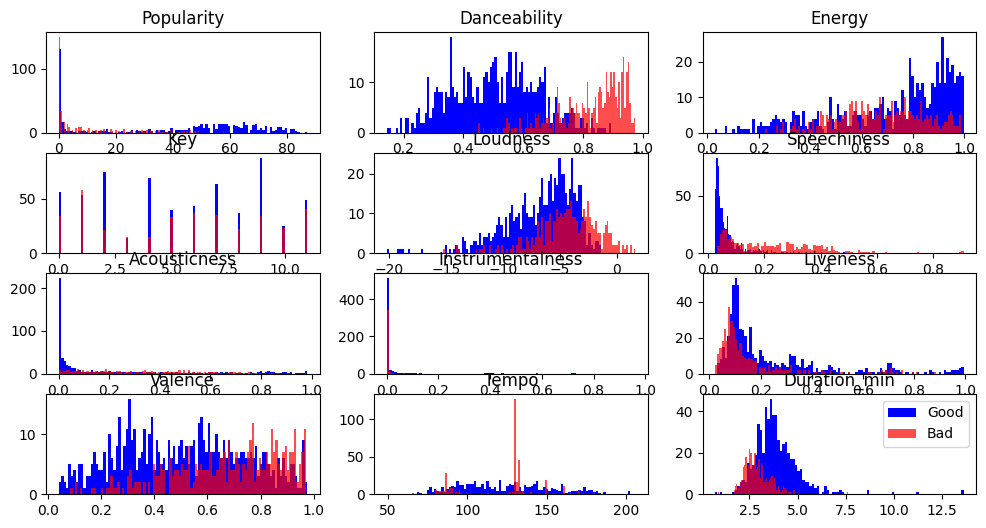

In [70]:
plot_hist_vs(X)

Plotting the distribution between each 25 different pairs of features (Plotando a distribuição entre cada 25 pares diferente das features).

Each time this code is run, it will plot different pairs, because there are more than 25 different pairs (Cada vez que esse código for executado, ele plotará pares diferentes, porque tem mais do que 25 pares diferentes).

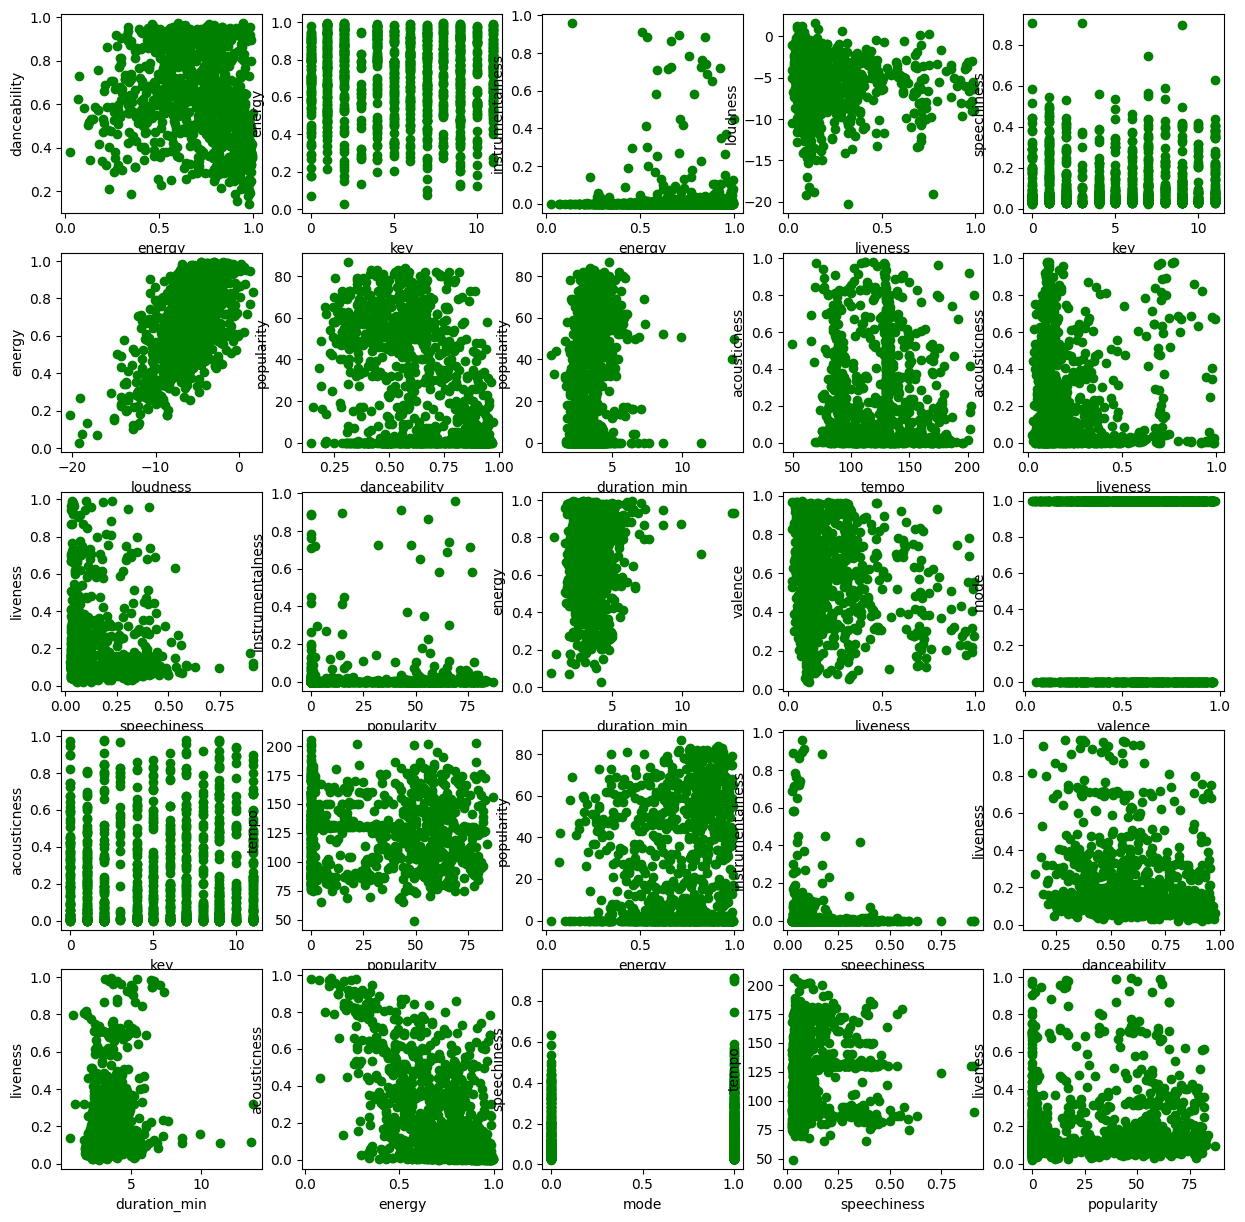

In [71]:
pairs = get_pairs(X_num)

fig, axs = plt.subplots(5, 5)
i = 0
for rows in axs:
    for ax in rows:
        ax.scatter(X_num[pairs[i][0]], X_num[pairs[i][1]], c='g')
        ax.set_xlabel(pairs[i][0])
        ax.set_ylabel(pairs[i][1])
        i+=1
plt.show()

Computing the correlation between each feature (Calculando a correlação entre cada feature).

In [72]:
X_corr = X_num.corr()
X_corr

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
popularity,1.000000,-0.384378,0.133587,0.012433,-0.146461,0.021448,-0.337709,-0.218468,0.015894,0.053100,-0.077873,-0.019295,0.221361
danceability,-0.384378,1.000000,-0.218017,-0.008203,0.196419,-0.010944,0.371626,0.251087,-0.110093,-0.240471,0.487388,-0.096490,-0.408243
energy,0.133587,-0.218017,1.000000,0.002421,0.607230,-0.119448,0.006405,-0.616818,0.007258,0.133774,0.176669,0.158513,0.095979
key,0.012433,-0.008203,0.002421,1.000000,-0.026120,-0.120825,-0.026196,0.013692,0.015681,0.026699,0.017331,-0.020200,-0.018467
loudness,-0.146461,0.196419,0.607230,-0.026120,1.000000,-0.124208,0.160003,-0.309100,-0.108615,-0.062711,0.201220,0.103914,-0.128506
mode,0.021448,-0.010944,-0.119448,-0.120825,-0.124208,1.000000,-0.004778,0.079664,0.054032,0.006375,-0.013359,0.027009,-0.082533
speechiness,-0.337709,0.371626,0.006405,-0.026196,0.160003,-0.004778,1.000000,0.147949,-0.082213,-0.021417,0.183768,-0.023927,-0.256856
acousticness,-0.218468,0.251087,-0.616818,0.013692,-0.309100,0.079664,0.147949,1.000000,-0.033782,0.015929,-0.078716,-0.096575,-0.165260
instrumentalness,0.015894,-0.110093,0.007258,0.015681,-0.108615,0.054032,-0.082213,-0.033782,1.000000,-0.011696,-0.068299,0.010875,0.074361
liveness,0.053100,-0.240471,0.133774,0.026699,-0.062711,0.006375,-0.021417,0.015929,-0.011696,1.000000,-0.172257,0.060445,0.166861


Applying a condition to view only correlations above a threshold and different from 1 (Aplicando uma condição para visualizar apenas as correlações acima de um threshold e diferente de 1).

In [73]:
mask = (abs(X_corr) > .4) & (abs(X_corr) != 1)
X_corr.where(mask).stack().sort_values(ascending=False)

energy        loudness        0.607230
loudness      energy          0.607230
valence       danceability    0.487388
danceability  valence         0.487388
duration_min  danceability   -0.408243
danceability  duration_min   -0.408243
energy        acousticness   -0.616818
acousticness  energy         -0.616818
dtype: float64

Plotting the heatmap with the correlation between all features (Plotando o heatmap com a correlação entre todas as features).

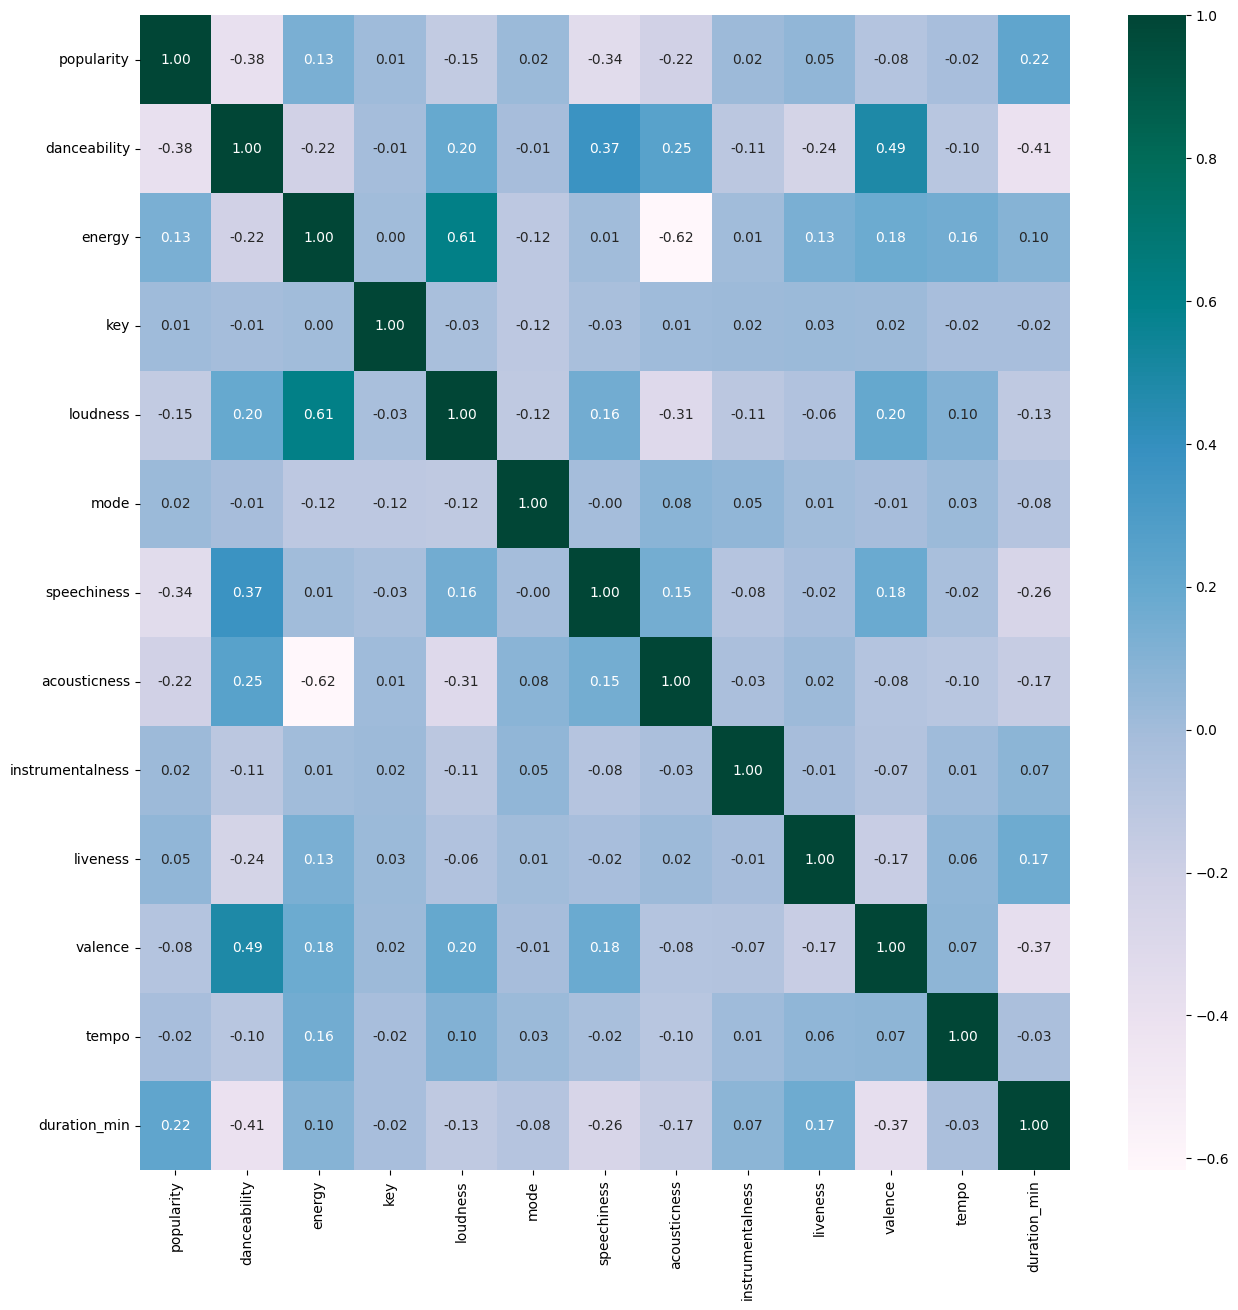

In [74]:
sns.heatmap(X_corr, annot=True, fmt='.2f', cmap='PuBuGn')
plt.show()

<a name="6"></a>
## Model

<a name="6.1"></a>
### Content-Based Filtering Algorithm
<img align='center' src='./images/content-based-filtering.png' style='width:400px;'>
    
O algoritmo Content-Based Filtering, é um algoritmo de recomendação, que recomenda itens ao usuário, usando como base as características do usuário e as características dos itens, para encontrar uma boa combinação.

Defining the number of features for the user and item neural network (Definindo o número de features para a rede neural do usuário e do item).

In [290]:
num_user_features, num_item_features = user_df.shape[1], X_num_oh.shape[1]
num_user_features, num_item_features

(13, 23)

Splitting the dataset between the training, validation and test sets (Dividindo o dataset entre o set de treino, validação e teste).

In [303]:
# Creating the column vector of the target label y to be divided along
# Criando o vetor de coluna do target label y para ser divido junto
y = X.iloc[:, -2].copy().to_numpy().reshape((-1, 1))

item_train, item_, y_train, y_ = train_test_split(X_num_oh, y, test_size=.4, shuffle=True, random_state=42)
user_train, user_ = train_test_split(user_df, test_size=.4, shuffle=True, random_state=42)
print(f'item_train.shape: {item_train.shape}\ny_train.shape: {y_train.shape}\n')
print(f'user_train.shape: {user_train.shape}\n')

item_cv, item_test, y_cv, y_test = train_test_split(item_, y_, test_size=.5, shuffle=True, random_state=42)
user_cv, user_test = train_test_split(user_, test_size=.5, shuffle=True, random_state=42)
print(f'item_cv.shape: {item_cv.shape}, item_test.shape: {item_test.shape}\ny_cv.shape: {y_cv.shape}, y_test.shape: {y_test.shape}\n')
print(f'user_cv.shape: {user_cv.shape}, user_test.shape: {user_test.shape}')

item_train.shape: (589, 23)
y_train.shape: (589, 1)

user_train.shape: (589, 13)

item_cv.shape: (196, 23), item_test.shape: (197, 23)
y_cv.shape: (196, 1), y_test.shape: (197, 1)

user_cv.shape: (196, 13), user_test.shape: (197, 13)


Applying z-score normalization to each dataset, so that they have a mean of 0 and a standard deviation of 1 (Aplicando a normalização z-score em cada dataset, para eles terem média 0 e desvio padrão 1).
$$X = \frac{X - \mu}{\sigma^2}$$

In [307]:
item_scaler = StandardScaler()
user_scaler = StandardScaler()

item_train_norm = item_scaler.fit_transform(item_train)
user_train_norm = user_scaler.fit_transform(user_train)

item_cv_norm = item_scaler.transform(item_cv)
user_cv_norm = user_scaler.transform(user_cv)

item_test_norm = item_scaler.transform(item_test)
user_test_norm = user_scaler.transform(user_test)

<a name="6.2"></a>
### Content-Based Filtering Model

Setting the model (Definindo o modelo).

In [310]:
LR = 1e-4
OPT = Adam(learning_rate=LR)
LOSS = MeanSquaredError()

model = model_compile(OPT, LOSS)
model.summary()

Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_45 (InputLayer)   │ (None, 13)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_47 (InputLayer)   │ (None, 23)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sequential_25 (Sequential)    │ (None, 32)                │          48,608 │ input_layer_45[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sequential_26 (Sequential)    │ (None, 32)                │          51,168 │ input_layer_47[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ l2__norm_24 (L2_Norm)         │ (None, 32)                │               0 │ sequential_25[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ l2__norm_25 (L2_Norm)         │ (None, 32)                │               0 │ sequential_26[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dot_12 (Dot)                  │ (None, 1)                 │               0 │ l2__norm_24[0][0],         │
│                               │                           │                 │ l2__norm_25[0][0]          │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 99,776 (389.75 KB)

 Trainable params: 97,984 (382.75 KB)

 Non-trainable params: 1,792 (7.00 KB)

Fitting the model (Treinando o modelo).

In [ ]:
history = model.fit([user_train_norm, item_train_norm], y_train, epochs=500, verbose=1)